# Feature Engineering: Форма и серии

Показатели текущей формы на уровне игрока:

- `winrate_last_N` - доля побед в последних N матчах
- `current_streak` - текущая серия: положительная = серия побед, отрицательная = серия поражений. 0 при отсутствии истории
- `quality_of_competition_N` - средний Elo соперников игрока в последних N матчах
- `elo_momentum_N` - изменение individual Elo игрока за последние N матчей (`elo_now - elo_N_matches_ago`)

Все фичи считаются для каждого игрока, затем на уровне команды берётся среднее двух игроков

Результат: `data/features/form_and_streaks.csv`

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from collections import defaultdict, deque

PROCESSED = Path("../../data/processed")
FEATURES = Path("../../data/features")

df = pd.read_csv(PROCESSED / "matches.csv", parse_dates=["played_at"])
df = df.sort_values("played_at").reset_index(drop=True)

elo = pd.read_csv(FEATURES / "elo.csv")
merged = df.merge(elo[["match_id", "elo_p1", "elo_p2", "elo_p3", "elo_p4"]], on="match_id")
merged = merged.sort_values("played_at").reset_index(drop=True)
print(f"Матчей: {len(merged)}")

Матчей: 2549


In [2]:
WINDOWS = [5, 10]

def compute_player_form(merged, windows=WINDOWS):
    W_MAX = max(windows)
    wins = defaultdict(lambda: deque(maxlen=W_MAX))           # 1/0 по последним матчам
    opps_elo = defaultdict(lambda: deque(maxlen=W_MAX))        # средний Elo соперников в последнем матче
    streak = defaultdict(int)                                  # текущая серия (+ победы / - поражения)
    elo_history = defaultdict(lambda: deque(maxlen=W_MAX + 1)) # post-match Elo каждого

    # pre-match Elo для текущего матча уже есть в merged как elo_p*
    records = []

    for _, row in merged.iterrows():
        p_ids = [row["player_id_1"], row["player_id_2"], row["player_id_3"], row["player_id_4"]]
        p_elos = [row["elo_p1"], row["elo_p2"], row["elo_p3"], row["elo_p4"]]
        sides = ["team_1", "team_1", "team_2", "team_2"]

        rec = {"match_id": row["match_id"]}

        team_vals = {"team_1": defaultdict(list), "team_2": defaultdict(list)}

        for p, pre_elo, side in zip(p_ids, p_elos, sides):
            w = wins[p]
            o = opps_elo[p]
            h = elo_history[p]

            for W in windows:
                recent_w = list(w)[-W:]
                team_vals[side][f"winrate_last{W}"].append(
                    (sum(recent_w) / len(recent_w)) if recent_w else np.nan
                )
                recent_o = list(o)[-W:]
                team_vals[side][f"qoc_last{W}"].append(
                    (sum(recent_o) / len(recent_o)) if recent_o else np.nan
                )
                hist = list(h)
                if len(hist) > W:
                    team_vals[side][f"elo_momentum_last{W}"].append(pre_elo - hist[-W - 1])
                else:
                    team_vals[side][f"elo_momentum_last{W}"].append(np.nan)

            team_vals[side]["current_streak"].append(streak[p])

        for side_name, prefix in [("team_1", "team1"), ("team_2", "team2")]:
            for k, vals in team_vals[side_name].items():
                rec[f"{prefix}_{k}"] = np.nanmean(vals) if len(vals) else np.nan

        records.append(rec)

        # Обновление состояний после записи признаков (pre-match)
        t1_won = row["winner"] == "team_1"
        # pre-match средний Elo соперника для каждого игрока
        opp_elo_mean_for_t1 = (row["elo_p3"] + row["elo_p4"]) / 2
        opp_elo_mean_for_t2 = (row["elo_p1"] + row["elo_p2"]) / 2

        for p, pre_elo, side in zip(p_ids, p_elos, sides):
            won = (t1_won and side == "team_1") or ((not t1_won) and side == "team_2")
            wins[p].append(1 if won else 0)
            opps_elo[p].append(opp_elo_mean_for_t1 if side == "team_1" else opp_elo_mean_for_t2)
            # post-match Elo неизвестен из текущего merged, но history хранит pre-match значения —
            # этого достаточно для momentum (разница pre_now - pre_(N назад))
            elo_history[p].append(pre_elo)
            if won:
                streak[p] = max(1, streak[p] + 1) if streak[p] >= 0 else 1
            else:
                streak[p] = min(-1, streak[p] - 1) if streak[p] <= 0 else -1

    return pd.DataFrame(records)

In [3]:
form = compute_player_form(merged, windows=WINDOWS)
print(f"Фич: {form.shape[1] - 1}")
print(form.describe())

/var/folders/3l/nhb2sbnj3lv7650ncvcld7j40000gq/T/ipykernel_6527/2466827930.py:46: RuntimeWarning: Mean of empty slice
  rec[f"{prefix}_{k}"] = np.nanmean(vals) if len(vals) else np.nan


Фич: 14
          match_id  team1_winrate_last5  team1_qoc_last5  \
count  2549.000000          2472.000000      2472.000000   
mean   2419.975284             0.523608      1605.032062   
std    2176.372145             0.249159        88.431179   
min      34.000000             0.000000      1391.227835   
25%     738.000000             0.400000      1535.738532   
50%    1463.000000             0.500000      1587.104453   
75%    3820.000000             0.666667      1660.238341   
max    7478.000000             1.000000      1982.028059   

       team1_elo_momentum_last5  team1_winrate_last10  team1_qoc_last10  \
count               2229.000000           2472.000000       2472.000000   
mean                   4.483801              0.527460       1602.089376   
std                   29.040034              0.226296         81.222590   
min                  -94.815124              0.000000       1391.227835   
25%                  -14.286754              0.391518       1537.358695   
5

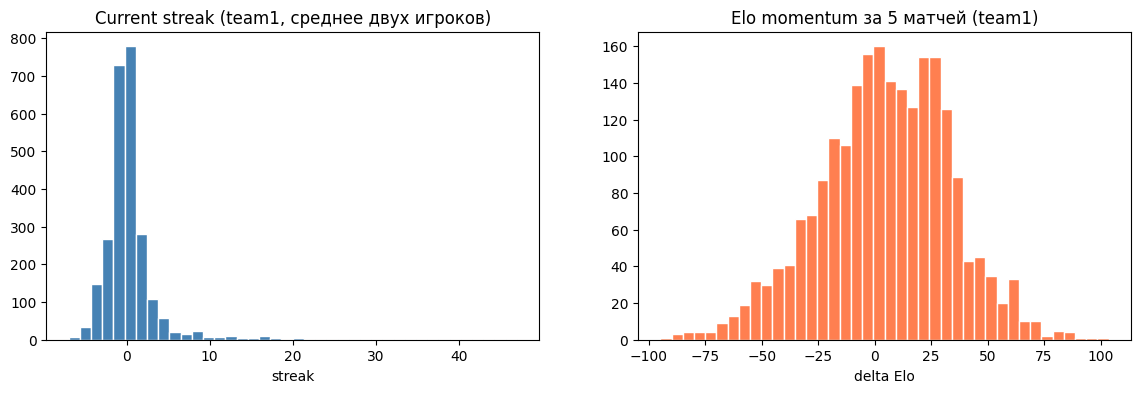

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(form["team1_current_streak"].dropna(), bins=40, color="steelblue", edgecolor="white")
axes[0].set_title("Current streak (team1, среднее двух игроков)")
axes[0].set_xlabel("streak")

axes[1].hist(form["team1_elo_momentum_last5"].dropna(), bins=40, color="coral", edgecolor="white")
axes[1].set_title("Elo momentum за 5 матчей (team1)")
axes[1].set_xlabel("delta Elo")
plt.show()

In [6]:
out_path = FEATURES / "form_and_streaks.csv"
form.to_csv(out_path, index=False)